<h1 style="margin:0;color:#3776AB;">🐍 Pythonize com Tomane | #026</h1>

### Criar um calendário de revisões com Python 📚

#### 💡 Sabias que podes transformar os assuntos que estudaste numa agenda automática de revisões?

Neste code, vou organizar as revisões de Python, inglês e francês. Basta escrever o assunto e o dia em que foi estudado. O programa cria uma agenda para os próximos dias, guarda um CSV e mostra num gráfico quais serão os dias mais ocupados.

Os assuntos abaixo são exemplos. Troca-os pelos teus antes de correres o notebook.


#### 1. Preparar as bibliotecas

Vamos usar `matplotlib` para o gráfico. `csv`, `datetime` e `collections` já vêm com Python.


In [ ]:
%pip install matplotlib


In [1]:
import csv
from collections import Counter
from datetime import date, timedelta
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

print("Prontos para montar o calendário! 🐍")


Prontos para montar o calendário! 🐍


#### 2. Escrever o que foi estudado

Coloca o assunto e a data em que o estudaste. Os intervalos de revisão deste exemplo são **1, 3, 7, 14 e 30 dias** após o estudo; podes alterá-los de acordo com a tua rotina.


In [2]:
hoje = date.today()

estudos = [
    {"assunto": "Python: web scraping", "data_estudo": hoje},
    {"assunto": "Inglês: vocabulário", "data_estudo": hoje - timedelta(days=1)},
    {"assunto": "Francês: verbos", "data_estudo": hoje - timedelta(days=2)},
]
intervalos = [1, 3, 7, 14, 30]

for item in estudos:
    print(f"{item['assunto']} | estudado em {item['data_estudo']:%d/%m/%Y}")


Python: web scraping | estudado em 23/09/2026
Inglês: vocabulário | estudado em 22/09/2026
Francês: verbos | estudado em 21/09/2026


#### 3. Gerar a agenda

Para cada assunto, vou somar os intervalos à data de estudo. As revisões cuja data já passou ficam fora desta agenda; as de hoje e as futuras aparecem por ordem de data.


In [3]:
agenda = []
for item in estudos:
    if item["data_estudo"] > hoje:
        raise ValueError(f"A data de estudo de {item['assunto']} está no futuro.")
    for numero, dias in enumerate(intervalos, start=1):
        data_revisao = item["data_estudo"] + timedelta(days=dias)
        if data_revisao >= hoje:
            agenda.append({
                "data": data_revisao,
                "assunto": item["assunto"],
                "revisao": numero,
                "dias_apos_estudo": dias,
            })

agenda.sort(key=lambda item: (item["data"], item["assunto"]))
print(f"Agenda criada: {len(agenda)} revisões a partir de hoje.")


Agenda criada: 14 revisões a partir de hoje.


#### 4. Ver as próximas revisões

Quero ver logo as sessões mais próximas, para planear a semana sem procurar entre todas as datas.


In [4]:
for item in agenda[:10]:
    print(f"{item['data']:%d/%m/%Y} | {item['assunto']} | revisão {item['revisao']}")


23/09/2026 | Inglês: vocabulário | revisão 1
24/09/2026 | Francês: verbos | revisão 2
24/09/2026 | Python: web scraping | revisão 1
25/09/2026 | Inglês: vocabulário | revisão 2
26/09/2026 | Python: web scraping | revisão 2
28/09/2026 | Francês: verbos | revisão 3
29/09/2026 | Inglês: vocabulário | revisão 3
30/09/2026 | Python: web scraping | revisão 3
05/10/2026 | Francês: verbos | revisão 4
06/10/2026 | Inglês: vocabulário | revisão 4


#### 5. Guardar a agenda em CSV

O ficheiro vai ficar na mesma pasta do notebook. Podes abri-lo no Excel e acrescentar uma coluna para marcar as revisões concluídas.


In [5]:
ficheiro = Path("Pythonize_026_Agenda_de_Revisoes.csv")
with ficheiro.open("w", encoding="utf-8-sig", newline="") as saida:
    escritor = csv.writer(saida)
    escritor.writerow(["data", "assunto", "numero_revisao", "dias_apos_estudo"])
    for item in agenda:
        escritor.writerow([
            item["data"].isoformat(), item["assunto"],
            item["revisao"], item["dias_apos_estudo"]
        ])

print(f"Agenda guardada em: {ficheiro.resolve()}")


Agenda guardada em: /workspace/scratch/6c2e783ccf52/test_026/Pythonize_026_Agenda_de_Revisoes.csv


#### 6. Ver as próximas duas semanas num gráfico 📊

Cada quadrado representa um dia. Quanto mais forte a cor, mais revisões estão marcadas para essa data. O gráfico à direita mostra as revisões de cada assunto ao longo da agenda.


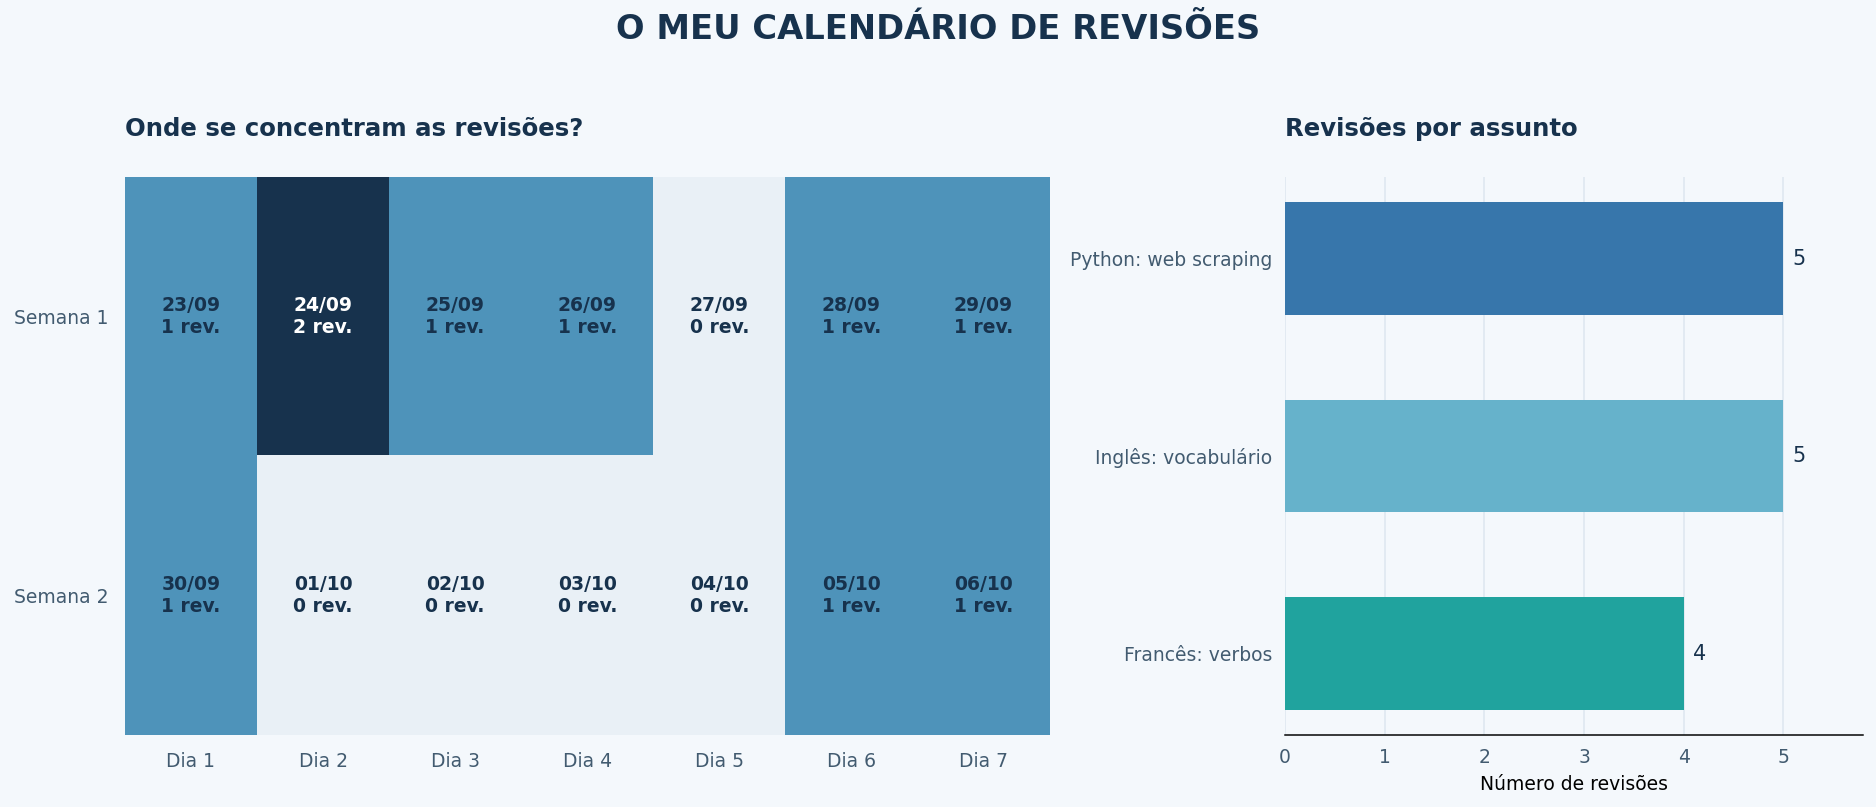

In [6]:
dias = [hoje + timedelta(days=passo) for passo in range(14)]
contagem_dias = Counter(item["data"] for item in agenda)
grade = np.array([contagem_dias[dia] for dia in dias]).reshape(2, 7)
contagem_assuntos = Counter(item["assunto"] for item in agenda)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.7),
                              gridspec_kw={"width_ratios": [1.6, 1]}, facecolor="#F4F8FC")
for ax in (ax1, ax2):
    ax.set_facecolor("#F4F8FC")

from matplotlib.colors import LinearSegmentedColormap
paleta = LinearSegmentedColormap.from_list("revisoes", ["#E9F0F6", "#66B2CB", "#3776AB", "#17324D"])
ax1.imshow(grade, cmap=paleta, vmin=0, vmax=max(1, int(grade.max())), aspect="auto")
ax1.set_xticks(range(7), [f"Dia {i}" for i in range(1, 8)])
ax1.set_yticks([0, 1], ["Semana 1", "Semana 2"])
ax1.set_title("Onde se concentram as revisões?", loc="left", color="#17324D",
              fontweight="bold", fontsize=13, pad=22)
ax1.tick_params(length=0, colors="#425B70", pad=9)
for linha in range(2):
    for coluna in range(7):
        indice = linha * 7 + coluna
        numero = grade[linha, coluna]
        cor = "white" if numero >= max(2, grade.max()) else "#17324D"
        ax1.text(coluna, linha, f"{dias[indice]:%d/%m}\n{numero} rev.",
                 ha="center", va="center", color=cor, fontsize=10, fontweight="bold")
for spine in ax1.spines.values():
    spine.set_visible(False)

assuntos = [item["assunto"] for item in estudos][::-1]
valores = [contagem_assuntos[assunto] for assunto in assuntos]
barras = ax2.barh(assuntos, valores, color=["#20A39E", "#66B2CB", "#3776AB"], height=0.57)
ax2.bar_label(barras, padding=5, color="#17324D", fontsize=11)
ax2.set_xlim(0, max(valores, default=0) + 0.8)
ax2.set_xticks(range(max(valores, default=0) + 1))
ax2.set_title("Revisões por assunto", loc="left", color="#17324D",
              fontweight="bold", fontsize=13, pad=22)
ax2.set_xlabel("Número de revisões")
ax2.spines[["top", "right", "left"]].set_visible(False)
ax2.grid(axis="x", color="#DDE6EF")
ax2.set_axisbelow(True)
ax2.tick_params(length=0, pad=7, colors="#425B70")

fig.suptitle("O MEU CALENDÁRIO DE REVISÕES", color="#17324D", fontsize=18,
             fontweight="bold", y=1.04)
fig.tight_layout()
plt.show()


### O que aprendemos?

Criámos um calendário de revisões a partir de assuntos e datas de estudo, guardámos a agenda num CSV e vimos num gráfico os dias mais preenchidos. Se a tua semana estiver muito cheia, ajusta os intervalos ou o número de assuntos no passo 2.


<h3 style="margin-bottom:5px;">
Tomane Mateus
</h3>

<p style="margin-top:0;">
</p>

<p>
🔗 <b>LinkedIn:</b>
<a href="https://www.linkedin.com/in/tomane-mateus-tomane-7a5205123" target="_blank">
www.linkedin.com/in/tomane-mateus-tomane-7a5205123
</a>
</p>
<p>
💻 <b>GitHub:</b>
<a href="https://github.com/Tomane-Pd" target="_blank">
github.com/Tomane-Pd
</a>
</p>
<p>
🌐 <b>Portfolio:</b>
<a href="https://tomane-portfolio.com" target="_blank">
tomane-portfolio.com
</a>
</p>

<hr style="border:1px solid #ddd; width:100%;">

<p style="color:#555;">
 <b>Siga para mais dicas práticas de Python, IA, Data Science e Automação.</b>
</p>

<p style="font-size:13px;color:#888;margin-top:15px;">
© 2026 <b>Tomane Mateus</b>. Todos os direitos reservados.
</p>

</div>